# Binary Fatigue (Low vs High): Centralized KNN vs Federated PSPFL — v2

Two-class fatigue detection, updated per feedback.

**Label (updated):**
* **Low**  = RPE 0–5
* **High** = RPE 6–10  (decision cut at 5.5)

**Work periods as separate 45-min samples (updated).** Each subject-condition record spans
**three 45-minute work periods** separated by recovery. Previously only the first period was
used. We now treat periods 1, 2, and 3 as **independent 45-minute samples** for the same
subject-condition — each re-zeroed to its own start. This multiplies the samples per
subject-condition and lets the recovery periods matter.

**Baseline (residual) fatigue as an input feature.** Because periods 2 and 3 begin with
leftover fatigue from incomplete recovery, each window carries a `baseline_rpe` feature = the
starting RPE of its work period. For most period-1 samples this is ≈ 0; for periods 2 and 3
it is typically > 0. This encodes "how tired the worker already was when this period began."

Everything else matches v1: **centralized KNN** (pools raw data) vs **PSPFL** (federated,
profile-similarity personalized linear SVM), compared on the same per-client test sets, for
the two recipes `acc+gyro|all|+anthro` and `acc+gyro|mean|+anthro`. No FedAvg.


## 0. Imports & configuration

**Work-period segmentation.** How the 3 periods are delimited in a session record depends on
the raw data, so `WORK_PERIOD_MODE` is configurable and defaults to `"auto"`:

* `"column"` — a per-row column marks the period (auto-detected among common names).
* `"gap"` — recovery shows up as a jump in `Timestamp` larger than `GAP_THRESHOLD_SEC`.
* `"fixed"` — one continuous timeline; cut into consecutive `PERIOD_LENGTH_MIN` chunks.
* `"session_is_period"` — each session already is a single period (fallback = old behaviour).

The load cell prints a diagnostic (periods found per session + mean baseline RPE by period)
so you can confirm the segmentation matches reality before trusting the results.


In [1]:
import pickle, warnings, copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import GridSearchCV, GroupKFold

warnings.filterwarnings("ignore")
SEED = 1365
np.random.seed(SEED)

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_PATH  = Path("C:/Users/sharv/OneDrive/Desktop/Worker_Fatigue_Dataset/NIOSH_Combined_Dataset.pkl")
OUTPUT_DIR = Path("outputs"); OUTPUT_DIR.mkdir(exist_ok=True)
CACHE_CSV  = OUTPUT_DIR / "task_features_periods.csv"   # per-work-period feature cache

# ── Cohort / tasks / sensors ─────────────────────────────────────────────────
EXCLUDE_SUBJECTS = {"Sub11", "Sub12", "Sub14"}
TASKS = [{"Weight": 2.5, "Pace": 15}, {"Weight": 2.5, "Pace": 10},
         {"Weight": 2.5, "Pace": 5},  {"Weight": 1.5, "Pace": 15}]
BODY_SEGMENTS = ["trunk", "upper_arm", "wrist"]
SENSOR_TYPES  = ["Accelerometer", "Gyroscope"]
AXES          = ["X", "Y", "Z"]
SENSOR_COLS   = [f"{seg}_{st}.{ax}" for seg in BODY_SEGMENTS
                 for st in SENSOR_TYPES for ax in AXES]
STATS         = ["mean", "std", "rms"]
ANTHRO_COLS   = ["anthro_Gender", "anthro_Age", "anthro_BMI", "anthro_WHR"]

FS, WINDOW_SIZE, STRIDE = 100, 1000, 500
MVIC_MINUTES, MVIC_BUFFER_SECONDS = [9, 18, 27, 36, 45], 60   # relative to EACH period start

# ── BINARY labels (UPDATED): Low = RPE 0-5, High = RPE 6-10, cut at 5.5 ──────
BINARY_CUT  = 5.5
RPE_LABELS  = ["Low", "High"]
CLASSES     = np.array([0, 1])

# ── Work-period segmentation (UPDATED) ───────────────────────────────────────
WORK_PERIOD_MODE  = "auto"     # auto | column | gap | fixed | session_is_period
PERIOD_COL_NAMES  = ["WorkPeriod", "Work_Period", "Period", "Block", "Bout",
                     "Trial", "Rep", "Segment", "Phase"]
GAP_THRESHOLD_SEC = 120        # Timestamp jump > this = a recovery gap ("gap" mode)
PERIOD_LENGTH_MIN = 45         # nominal work-period length ("fixed" mode)
MAX_PERIODS       = 3          # expected number of work periods per session
INCLUDE_BASELINE  = True       # add baseline_rpe (residual fatigue) as a model feature

# ── The two recipes to evaluate ──────────────────────────────────────────────
RECIPES = [
    {"name": "acc+gyro|all|+anthro",
     "sensors": ("Accelerometer", "Gyroscope"), "stats": ("mean", "std", "rms"), "anthro": True},
    {"name": "acc+gyro|mean|+anthro",
     "sensors": ("Accelerometer", "Gyroscope"), "stats": ("mean",), "anthro": True},
]

# ── PSPFL / federated hyperparameters ────────────────────────────────────────
PSPFL_LOSS    = "hinge"        # 'hinge' = linear SVM (default), 'log_loss' = logistic
COMM_ROUNDS   = 12
LOCAL_EPOCHS  = 10
RATE          = 1.0
RATIO_GRID    = [0.0, 0.1, 0.3, 0.5]
SGD_ALPHA     = 1e-4
NORMALIZE_BLEND = True
TEST_FRAC     = 0.30

print(f"Binary cut at RPE {BINARY_CUT} (Low 0-5 / High 6-10)")
print(f"Work-period mode: {WORK_PERIOD_MODE}, up to {MAX_PERIODS} periods, "
      f"baseline feature: {INCLUDE_BASELINE}")


Binary cut at RPE 5.5 (Low 0-5 / High 6-10)
Work-period mode: auto, up to 3 periods, baseline feature: True


## 1. Work-period segmentation + feature extraction

`segment_work_periods()` splits one session record into its constituent 45-min work periods.
For each period we re-zero elapsed time, mask the MVIC strength tests **relative to that
period's start**, record the period's **baseline RPE** (first reading ≈ residual fatigue),
interpolate RPE within the period, and slide the usual 10-s windows to compute
`mean/std/rms` per channel. The window label is its median RPE binned at 5.5.


In [2]:
def session_to_task(settings, subject, session, tasks=TASKS):
    """Map (subject, session) to a task index by matching (Weight, Pace)."""
    if subject not in settings:
        return None
    df_set = pd.DataFrame(settings[subject]).copy()
    df_set.columns = [str(c).capitalize() for c in df_set.columns]
    if session not in df_set.index:
        return None
    w, p = float(df_set.loc[session, "Weight"]), float(df_set.loc[session, "Pace"])
    for ti, t in enumerate(tasks):
        if np.isclose(w, t["Weight"]) and np.isclose(p, t["Pace"]):
            return ti
    return None


def build_anthro_lookup(anthro):
    """Per-subject anthropometrics (used as features AND for the similarity matrix)."""
    a = anthro.copy()
    a["anthro_Gender"] = a["Gender"].astype(str).str.upper().str[0].map({"M": 1, "F": 0})
    a["anthro_Age"]    = pd.to_numeric(a["Age"], errors="coerce")
    a["anthro_BMI"]    = a["Weight (kg)"] / (a["Height (cm)"] / 100.0) ** 2
    a["anthro_WHR"]    = a["Waist circumference (cm)"] / a["Hip circumference (cm)"]
    return a.set_index("Subject")[ANTHRO_COLS].to_dict("index")


def _find_period_col(df):
    """Return the first period-marking column that actually varies, else None."""
    for c in PERIOD_COL_NAMES:
        if c in df.columns and df[c].nunique(dropna=True) > 1:
            return c
    return None


def segment_work_periods(df, mode=WORK_PERIOD_MODE):
    """
    Split a single session record into a list of work-period sub-DataFrames.

    Strategy (mode='auto' resolves in this order):
      column  -> group by an explicit period column
      gap     -> cut wherever Timestamp jumps by > GAP_THRESHOLD_SEC (recovery)
      fixed   -> cut a continuous timeline into PERIOD_LENGTH_MIN chunks
      session_is_period -> the whole record is one period (old behaviour)

    Fragments shorter than one window are dropped; at most MAX_PERIODS are kept.
    """
    df = df.sort_values("Timestamp").reset_index(drop=True)
    ts = df["Timestamp"].values

    if mode == "auto":
        if _find_period_col(df) is not None:
            mode = "column"
        elif len(ts) > 1 and np.any(np.diff(ts) > GAP_THRESHOLD_SEC):
            mode = "gap"
        elif len(ts) > 1 and (ts[-1] - ts[0]) / 60.0 > PERIOD_LENGTH_MIN * 1.2:
            mode = "fixed"
        else:
            mode = "session_is_period"

    periods = []
    if mode == "column":
        col = _find_period_col(df)
        for _, g in df.groupby(col, sort=True):
            periods.append(g.reset_index(drop=True))
    elif mode == "gap":
        cuts = np.where(np.diff(ts) > GAP_THRESHOLD_SEC)[0]
        bounds = [0] + list(cuts + 1) + [len(df)]
        for a, b in zip(bounds[:-1], bounds[1:]):
            periods.append(df.iloc[a:b].reset_index(drop=True))
    elif mode == "fixed":
        elapsed = (ts - ts[0]) / 60.0
        p = 0
        while p < MAX_PERIODS:
            seg = df[(elapsed >= p * PERIOD_LENGTH_MIN) & (elapsed < (p + 1) * PERIOD_LENGTH_MIN)]
            if seg.empty:
                break
            periods.append(seg.reset_index(drop=True)); p += 1
    else:  # session_is_period
        periods = [df]

    periods = [p for p in periods if len(p) >= WINDOW_SIZE][:MAX_PERIODS]
    return periods


def period_baseline_rpe(pdf):
    """Residual fatigue at a period's start = its first recorded RPE (0 if none)."""
    valid = pdf["RPE_Val"].astype(float).dropna()
    return float(valid.iloc[0]) if len(valid) else 0.0


def rebuild_features(data_path):
    """Window every work period into labelled feature rows (sensor stats + anthro + baseline)."""
    with open(data_path, "rb") as f:
        data = pickle.load(f)
    ts_data  = {k: v for k, v in data["ts_data"].items() if k[0] not in EXCLUDE_SUBJECTS}
    anthro   = data["anthro_clean"]
    anthro   = anthro[~anthro["Subject"].isin(EXCLUDE_SUBJECTS)].reset_index(drop=True)
    settings = data["experiment_settings"]
    lkp      = build_anthro_lookup(anthro)

    rows, period_report = [], []
    for (subj, sess), df in sorted(ts_data.items()):
        task = session_to_task(settings, subj, sess)
        if task is None:
            continue
        if "Session" in df.columns:
            df = df[df["Session"].astype(str).str.strip() == sess].copy()
        if df.empty or any(c not in df.columns for c in SENSOR_COLS):
            continue

        periods = segment_work_periods(df)
        period_report.append((subj, sess, len(periods)))

        for wp_idx, pdf in enumerate(periods):
            baseline = period_baseline_rpe(pdf)
            rpe = pdf["RPE_Val"].astype(float).interpolate("linear").bfill().ffill().values
            imu = pdf[SENSOR_COLS].values.astype(np.float32)
            elapsed = pdf["Timestamp"].values - pdf["Timestamp"].iloc[0]     # re-zeroed per period
            mvic = np.zeros(len(pdf), bool)
            for tm in MVIC_MINUTES:
                mvic |= np.abs(elapsed - tm * 60) <= MVIC_BUFFER_SECONDS
            n, start = len(pdf), 0
            while start + WINDOW_SIZE <= n:
                sl = slice(start, start + WINDOW_SIZE)
                if mvic[sl].any() or np.isnan(imu[sl]).any():
                    start += STRIDE; continue
                rr = rpe[sl][~np.isnan(rpe[sl])]
                if rr.size == 0:
                    start += STRIDE; continue
                win = imu[sl]
                row = {"Subject": subj, "Task": task, "WorkPeriod": wp_idx,
                       "baseline_rpe": baseline, "rpe_median": float(np.median(rr))}
                mean, std = win.mean(0), win.std(0)
                rms = np.sqrt((win ** 2).mean(0))
                for j, ch in enumerate(SENSOR_COLS):
                    row[f"{ch}_mean"], row[f"{ch}_std"], row[f"{ch}_rms"] = \
                        float(mean[j]), float(std[j]), float(rms[j])
                row.update(lkp.get(subj, {}))
                rows.append(row); start += STRIDE

    feat = pd.DataFrame(rows)
    rep = pd.DataFrame(period_report, columns=["Subject", "Session", "n_periods"])
    return feat, rep


if Path(CACHE_CSV).exists():
    print(f"Loading cached features from {CACHE_CSV}")
    feat_df = pd.read_csv(CACHE_CSV); period_rep = None
else:
    print("Building per-work-period features from pickle ...")
    feat_df, period_rep = rebuild_features(DATA_PATH)
    feat_df.to_csv(CACHE_CSV, index=False)
    print(f"Cached -> {CACHE_CSV}")

SENSOR_FEATS = [f"{ch}_{s}" for ch in SENSOR_COLS for s in STATS]
feat_df = feat_df.dropna(subset=SENSOR_FEATS + ANTHRO_COLS + ["rpe_median", "baseline_rpe"]).reset_index(drop=True)
feat_df["y"] = (feat_df["rpe_median"] > BINARY_CUT).astype(int)

# ── Diagnostics: confirm the segmentation looks right ────────────────────────
if period_rep is not None:
    print("\nWork periods detected per session (distribution):")
    print(period_rep["n_periods"].value_counts().sort_index().to_string())
print(f"\n{len(feat_df):,} windows from {feat_df['Subject'].nunique()} subjects "
      f"(vs first-period-only before)")
print("\nMean baseline RPE by work period (should rise 1->2->3 due to residual fatigue):")
print(feat_df.groupby("WorkPeriod")["baseline_rpe"].mean().round(2).to_string())
print("\nBinary class balance:")
print(feat_df["y"].map(dict(enumerate(RPE_LABELS))).value_counts().to_string())


Building per-work-period features from pickle ...
Cached -> outputs\task_features_periods.csv

Work periods detected per session (distribution):
n_periods
1    55

21,923 windows from 14 subjects (vs first-period-only before)

Mean baseline RPE by work period (should rise 1->2->3 due to residual fatigue):
WorkPeriod
0    0.11

Binary class balance:
y
Low     16793
High     5130


## 2. Recipe → feature columns

`baseline_rpe` is appended to every recipe's feature vector (when `INCLUDE_BASELINE`), so the
residual-fatigue context is available to both KNN and PSPFL.


In [3]:
def select_columns(sensors, stats, anthro, baseline=INCLUDE_BASELINE):
    """Feature columns for a recipe: sensor-type x statistic, +anthro, + baseline_rpe."""
    cols = [f"{ch}_{st}" for ch in SENSOR_COLS for st in stats
            if any(s in ch for s in sensors)]
    if anthro:
        cols = cols + ANTHRO_COLS
    if baseline:
        cols = cols + ["baseline_rpe"]
    return cols

for r in RECIPES:
    r["cols"] = select_columns(r["sensors"], r["stats"], r["anthro"])
    print(f"{r['name']:24s} -> {len(r['cols'])} features "
          f"(incl. baseline_rpe={INCLUDE_BASELINE})")


acc+gyro|all|+anthro     -> 59 features (incl. baseline_rpe=True)
acc+gyro|mean|+anthro    -> 23 features (incl. baseline_rpe=True)


## 3. Clients, global scaling, and profile similarity

Each subject is a client; its windows now come from up to 3 work periods across 4 tasks. A
global scaler (fit on pooled training windows) is broadcast for coherent weight averaging;
the PSPFL similarity matrix is cosine similarity over normalized anthropometrics.


In [4]:
def per_client_split(y, test_frac=TEST_FRAC, seed=SEED):
    """Stratified per-client train/test indices, robust to tiny/absent classes."""
    rng = np.random.default_rng(seed)
    tr, te = [], []
    for c in np.unique(y):
        ci = np.where(y == c)[0]; rng.shuffle(ci)
        n_tr = max(1, int(round(len(ci) * (1 - test_frac))))
        n_tr = min(n_tr, len(ci) - 1) if len(ci) > 1 else len(ci)
        tr += list(ci[:n_tr]); te += list(ci[n_tr:])
    return np.array(tr, int), np.array(te, int)


def build_clients(feat_df, cols):
    """Per-client scaled arrays + a global StandardScaler; client order fixes similarity index."""
    order = sorted(feat_df["Subject"].unique())
    raw, pooled = {}, []
    for s in order:
        d = feat_df[feat_df["Subject"] == s]
        X = d[cols].values.astype(float); y = d["y"].values.astype(int)
        tr, te = per_client_split(y)
        raw[s] = (X[tr], y[tr], X[te], y[te]); pooled.append(X[tr])
    scaler = StandardScaler().fit(np.vstack(pooled))
    clients = []
    for s in order:
        Xtr, ytr, Xte, yte = raw[s]
        clients.append({"subject": s, "Xtr": scaler.transform(Xtr), "ytr": ytr,
                        "Xte": scaler.transform(Xte), "yte": yte})
    return clients, order


def build_similarity(feat_df, order):
    """Cosine similarity over min-max-normalized anthropometric profiles."""
    prof = feat_df.groupby("Subject")[ANTHRO_COLS].first().loc[order].values.astype(float)
    mn, mx = prof.min(0), prof.max(0)
    return cosine_similarity((prof - mn) / (mx - mn + 1e-12))


_clients, _order = build_clients(feat_df, RECIPES[0]["cols"])
print(f"{len(_clients)} clients; train/test sizes (first 3): "
      f"{[(c['Xtr'].shape[0], c['Xte'].shape[0]) for c in _clients[:3]]}")


14 clients; train/test sizes (first 3): [(1186, 508), (1184, 508), (748, 321)]


## 4. Federated learner internals (binary-safe)

For binary classification `SGDClassifier` stores `coef_` of shape (1, n_features) and
`intercept_` of shape (1,) — `zeros_w` accounts for that. Standard federated client: warm
start, local `partial_fit` epochs, predict-from-weights.


In [5]:
def make_sgd(loss=PSPFL_LOSS):
    """Linear base learner: 'hinge' = SVM, 'log_loss' = logistic regression."""
    return SGDClassifier(loss=loss, alpha=SGD_ALPHA, learning_rate="optimal", random_state=SEED)

def get_w(clf):
    return [clf.coef_.copy(), clf.intercept_.copy()]

def set_w(clf, W):
    clf.coef_ = W[0].copy(); clf.intercept_ = W[1].copy()

def zeros_w(n_features):
    """Zero weights with the correct shape (binary SGD uses a single weight row)."""
    k = 1 if len(CLASSES) == 2 else len(CLASSES)
    return [np.zeros((k, n_features)), np.zeros(k)]

def _shape_init(clf, X):
    """Initialize coef_/intercept_ shapes without committing a meaningful update."""
    m = min(len(X), 3)
    dummy = np.array([CLASSES[i % len(CLASSES)] for i in range(m)])
    clf.partial_fit(X[:m], dummy, classes=CLASSES)

def local_update(Xtr, ytr, init_W, loss=PSPFL_LOSS, local_epochs=LOCAL_EPOCHS):
    """Warm-start from init_W and run local_epochs shuffled partial_fit passes. Data stays local."""
    clf = make_sgd(loss); _shape_init(clf, Xtr)
    if init_W is not None:
        set_w(clf, init_W)
    rng = np.random.default_rng(SEED)
    for _ in range(local_epochs):
        idx = rng.permutation(len(Xtr)); clf.partial_fit(Xtr[idx], ytr[idx])
    return get_w(clf)

def predict_w(W, X, loss=PSPFL_LOSS):
    """Predict labels from a raw weight set."""
    clf = make_sgd(loss); _shape_init(clf, X); set_w(clf, W)
    return clf.predict(X)

def eval_W(W, X, y, loss=PSPFL_LOSS):
    """Metrics + predictions for a weight set on (X, y)."""
    if len(y) == 0:
        return dict(macro_f1=np.nan, accuracy=np.nan, high_recall=np.nan,
                    high_precision=np.nan), np.array([]), np.array([])
    p = predict_w(W, X, loss)
    return (dict(macro_f1=f1_score(y, p, average="macro", zero_division=0),
                 accuracy=accuracy_score(y, p),
                 high_recall=recall_score(y, p, pos_label=1, zero_division=0),
                 high_precision=precision_score(y, p, pos_label=1, zero_division=0)),
            y, p)


## 5. PSPFL training loop

Each client keeps a persistent personalized weight set; each round it trains locally, then
blends in other clients' fresh weights scaled by profile similarity
(`W_i += ratio·rate·Σ_j sim_ij·W_j`, similarity-normalized). Each client is scored with its
own model. `ratio = 0` ⇒ independent per-client models.


In [6]:
def run_pspfl(clients, sim, ratio, loss=PSPFL_LOSS, rounds=COMM_ROUNDS,
              rate=RATE, normalize=NORMALIZE_BLEND):
    """Returns (per-client metrics, mean test-F1 history, pooled y_true, pooled y_pred)."""
    n = len(clients); n_feat = clients[0]["Xtr"].shape[1]
    W = [zeros_w(n_feat) for _ in range(n)]
    hist = []
    for _ in range(rounds):
        fresh = [local_update(clients[i]["Xtr"], clients[i]["ytr"], W[i], loss) for i in range(n)]
        new_W = []
        for i in range(n):
            denom = sum(sim[i][j] for j in range(n) if j != i) if normalize else 1.0
            denom = denom if denom > 1e-12 else 1.0
            blended = [layer.copy() for layer in fresh[i]]
            for j in range(n):
                if j == i:
                    continue
                coeff = ratio * rate * sim[i][j] / denom
                for l in range(len(blended)):
                    blended[l] += fresh[j][l] * coeff
            new_W.append(blended)
        W = new_W
        f1s = [eval_W(W[i], clients[i]["Xte"], clients[i]["yte"], loss)[0]["macro_f1"]
               for i in range(n)]
        hist.append(np.nanmean(f1s))
    metrics, yt_all, yp_all = [], [], []
    for i in range(n):
        m, yt, yp = eval_W(W[i], clients[i]["Xte"], clients[i]["yte"], loss)
        metrics.append(m); yt_all.extend(yt); yp_all.extend(yp)
    return metrics, hist, np.array(yt_all), np.array(yp_all)


## 6. Centralized KNN baseline

Pool every client's training windows, tune `k` with subject-grouped CV, evaluate on each
client's test set — the non-private reference.


In [7]:
def run_centralized_knn(clients, k_grid=(5, 11, 21)):
    """Returns (per-client metrics, best_k, pooled y_true, pooled y_pred)."""
    Xtr = np.vstack([c["Xtr"] for c in clients])
    ytr = np.concatenate([c["ytr"] for c in clients])
    groups = np.concatenate([[c["subject"]] * len(c["ytr"]) for c in clients])
    gkf = GroupKFold(n_splits=min(5, len(clients)))
    search = GridSearchCV(KNeighborsClassifier(weights="distance", n_jobs=-1),
                          {"n_neighbors": list(k_grid)}, scoring="f1_macro",
                          cv=gkf, n_jobs=-1).fit(Xtr, ytr, groups=groups)
    knn = search.best_estimator_
    metrics, yt_all, yp_all = [], [], []
    for c in clients:
        if len(c["yte"]) == 0:
            continue
        p = knn.predict(c["Xte"]); y = c["yte"]
        metrics.append(dict(macro_f1=f1_score(y, p, average="macro", zero_division=0),
                            accuracy=accuracy_score(y, p),
                            high_recall=recall_score(y, p, pos_label=1, zero_division=0),
                            high_precision=precision_score(y, p, pos_label=1, zero_division=0)))
        yt_all.extend(y); yp_all.extend(p)
    return metrics, search.best_params_["n_neighbors"], np.array(yt_all), np.array(yp_all)


## 7. Run KNN vs PSPFL for both recipes


In [8]:
def mean_metric(metrics, key):
    return float(np.nanmean([m[key] for m in metrics]))

results, preds, histories = [], {}, {}
for recipe in RECIPES:
    clients, order = build_clients(feat_df, recipe["cols"])
    sim = build_similarity(feat_df, order)

    knn_m, best_k, knn_yt, knn_yp = run_centralized_knn(clients)
    results.append(dict(recipe=recipe["name"], model="KNN (centralized)", ratio=np.nan, k=best_k,
                        macro_f1=mean_metric(knn_m, "macro_f1"),
                        accuracy=mean_metric(knn_m, "accuracy"),
                        high_recall=mean_metric(knn_m, "high_recall"),
                        high_precision=mean_metric(knn_m, "high_precision")))
    preds[(recipe["name"], "KNN (centralized)")] = (knn_yt, knn_yp)
    print(f"[{recipe['name']}] KNN(centralized) k={best_k}: "
          f"macroF1={results[-1]['macro_f1']:.3f}  acc={results[-1]['accuracy']:.3f}")

    for ratio in RATIO_GRID:
        ps_m, ps_hist, ps_yt, ps_yp = run_pspfl(clients, sim, ratio)
        name = f"PSPFL r={ratio}"
        results.append(dict(recipe=recipe["name"], model=name, ratio=ratio, k=np.nan,
                            macro_f1=mean_metric(ps_m, "macro_f1"),
                            accuracy=mean_metric(ps_m, "accuracy"),
                            high_recall=mean_metric(ps_m, "high_recall"),
                            high_precision=mean_metric(ps_m, "high_precision")))
        preds[(recipe["name"], name)] = (ps_yt, ps_yp)
        histories[(recipe["name"], name)] = ps_hist
        print(f"[{recipe['name']}] {name}: macroF1={results[-1]['macro_f1']:.3f}  "
              f"acc={results[-1]['accuracy']:.3f}")

res_df = pd.DataFrame(results).sort_values(["recipe", "macro_f1"], ascending=[True, False])
res_df.reset_index(drop=True, inplace=True)
res_df


[acc+gyro|all|+anthro] KNN(centralized) k=11: macroF1=0.830  acc=0.868
[acc+gyro|all|+anthro] PSPFL r=0.0: macroF1=0.833  acc=0.855
[acc+gyro|all|+anthro] PSPFL r=0.1: macroF1=0.810  acc=0.852
[acc+gyro|all|+anthro] PSPFL r=0.3: macroF1=0.587  acc=0.754
[acc+gyro|all|+anthro] PSPFL r=0.5: macroF1=0.560  acc=0.745
[acc+gyro|mean|+anthro] KNN(centralized) k=5: macroF1=0.797  acc=0.838
[acc+gyro|mean|+anthro] PSPFL r=0.0: macroF1=0.759  acc=0.793
[acc+gyro|mean|+anthro] PSPFL r=0.1: macroF1=0.784  acc=0.817
[acc+gyro|mean|+anthro] PSPFL r=0.3: macroF1=0.626  acc=0.766
[acc+gyro|mean|+anthro] PSPFL r=0.5: macroF1=0.560  acc=0.745


,recipe,model,ratio,k,macro_f1,accuracy,high_recall,high_precision
0,acc+gyro|all|+anthro,PSPFL r=0.0,0.0,NaN,0.833071,0.854593,0.572715,0.506847
1,acc+gyro|all|+anthro,KNN (centralized),NaN,11.0,0.830324,0.867871,0.475916,0.559260
2,acc+gyro|all|+anthro,PSPFL r=0.1,0.1,NaN,0.809908,0.851618,0.389805,0.579178
3,acc+gyro|all|+anthro,PSPFL r=0.3,0.3,NaN,0.587286,0.753992,0.028168,0.406349
4,acc+gyro|all|+anthro,PSPFL r=0.5,0.5,NaN,0.559890,0.744827,0.000000,0.000000
5,acc+gyro|mean|+anthro,KNN (centralized),NaN,5.0,0.796791,0.838490,0.439777,0.490490
6,acc+gyro|mean|+anthro,PSPFL r=0.1,0.1,NaN,0.783590,0.816660,0.435785,0.481828
7,acc+gyro|mean|+anthro,PSPFL r=0.0,0.0,NaN,0.758984,0.793494,0.529963,0.416896
8,acc+gyro|mean|+anthro,PSPFL r=0.3,0.3,NaN,0.625942,0.766396,0.088739,0.380316
9,acc+gyro|mean|+anthro,PSPFL r=0.5,0.5,NaN,0.560378,0.744977,0.000455,0.071429


## 8. Comparison plots


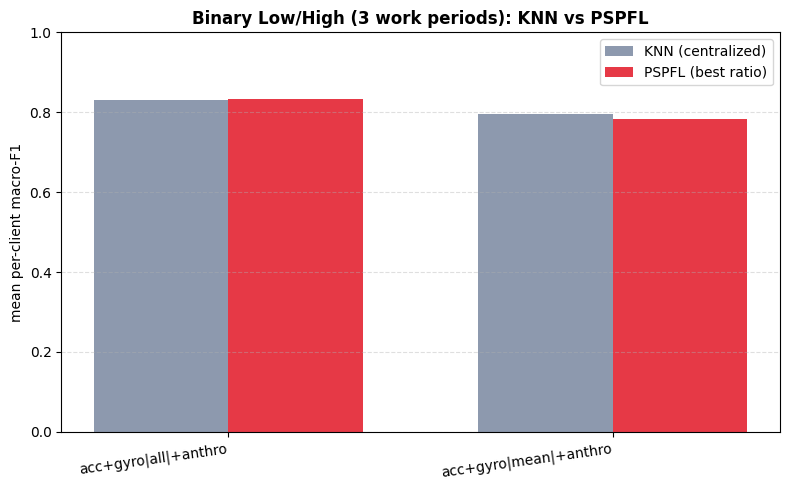

,recipe,KNN,PSPFL_best,PSPFL_cfg
0,acc+gyro|all|+anthro,0.8303,0.8331,PSPFL r=0.0
1,acc+gyro|mean|+anthro,0.7968,0.7836,PSPFL r=0.1


In [9]:
def is_pspfl(m): return m.startswith("PSPFL")
rows = []
for recipe in RECIPES:
    sub = res_df[res_df["recipe"] == recipe["name"]]
    knn = sub[sub["model"] == "KNN (centralized)"]["macro_f1"].iloc[0]
    bp  = sub[sub["model"].map(is_pspfl)].sort_values("macro_f1", ascending=False).iloc[0]
    rows.append((recipe["name"], knn, bp["macro_f1"], bp["model"]))
cmp_df = pd.DataFrame(rows, columns=["recipe", "KNN", "PSPFL_best", "PSPFL_cfg"])

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(cmp_df)); w = 0.35
ax.bar(x - w/2, cmp_df["KNN"], w, label="KNN (centralized)", color="#8D99AE")
ax.bar(x + w/2, cmp_df["PSPFL_best"], w, label="PSPFL (best ratio)", color="#E63946")
ax.set_xticks(x); ax.set_xticklabels(cmp_df["recipe"], rotation=8, ha="right")
ax.set_ylabel("mean per-client macro-F1"); ax.set_ylim(0, 1)
ax.set_title("Binary Low/High (3 work periods): KNN vs PSPFL", fontweight="bold")
ax.legend(); ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "binary_knn_vs_pspfl.png", dpi=150, bbox_inches="tight")
plt.show()
cmp_df.round(4)


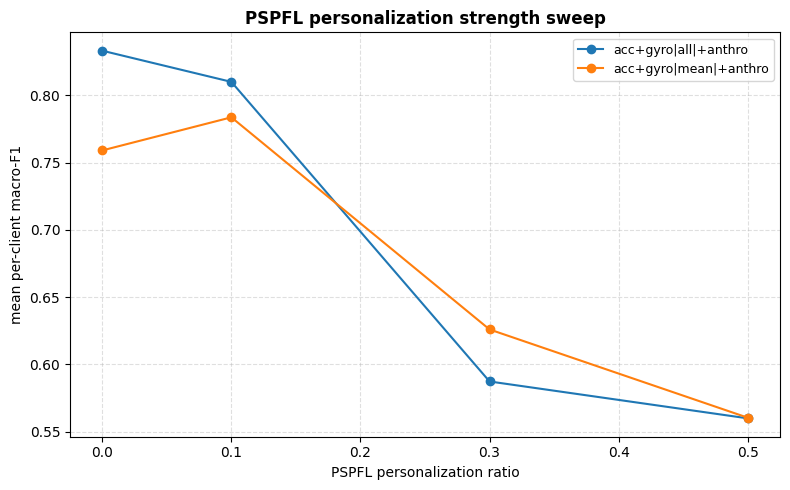

In [10]:
# PSPFL ratio sweep
fig, ax = plt.subplots(figsize=(8, 5))
for recipe in RECIPES:
    sub = res_df[(res_df["recipe"] == recipe["name"]) & (res_df["model"].map(is_pspfl))].sort_values("ratio")
    ax.plot(sub["ratio"], sub["macro_f1"], "-o", label=recipe["name"])
ax.set_xlabel("PSPFL personalization ratio"); ax.set_ylabel("mean per-client macro-F1")
ax.set_title("PSPFL personalization strength sweep", fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "binary_pspfl_ratio_sweep.png", dpi=150, bbox_inches="tight")
plt.show()


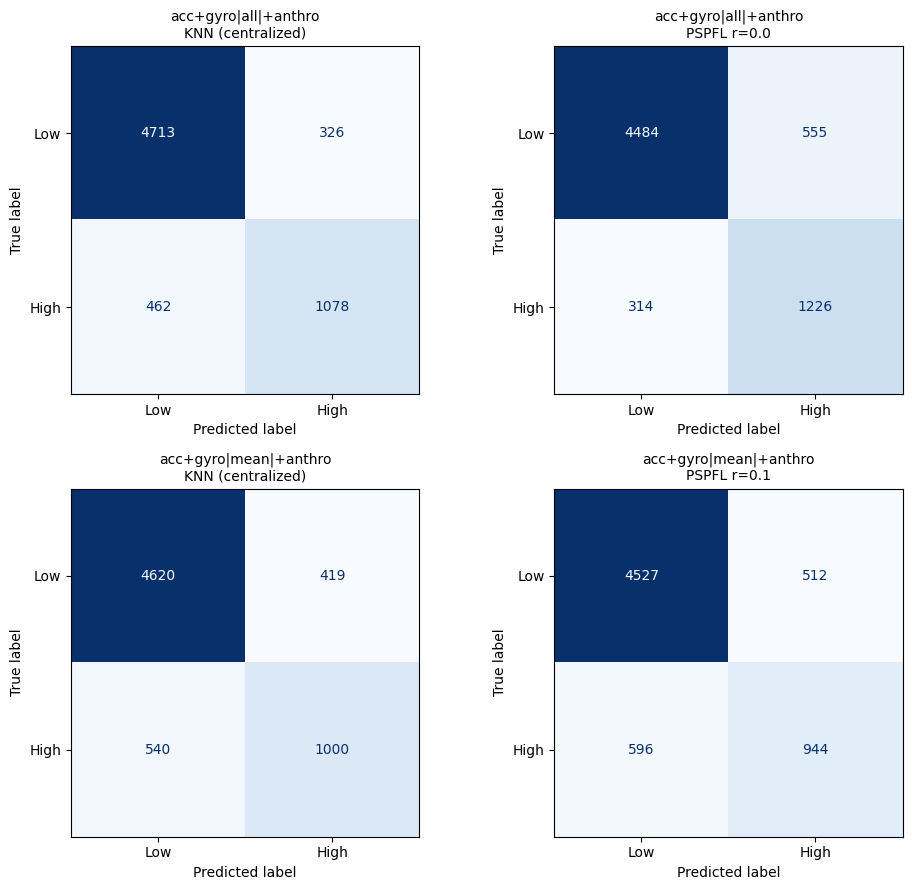

In [11]:
# Confusion matrices: KNN vs best PSPFL, per recipe
fig, axes = plt.subplots(len(RECIPES), 2, figsize=(10, 4.5 * len(RECIPES)))
axes = np.atleast_2d(axes)
for r, recipe in enumerate(RECIPES):
    best_pspfl = cmp_df[cmp_df["recipe"] == recipe["name"]]["PSPFL_cfg"].iloc[0]
    for c, model in enumerate(["KNN (centralized)", best_pspfl]):
        yt, yp = preds[(recipe["name"], model)]
        cm = confusion_matrix(yt, yp, labels=[0, 1])
        ConfusionMatrixDisplay(cm, display_labels=RPE_LABELS).plot(
            ax=axes[r, c], cmap="Blues", colorbar=False)
        axes[r, c].set_title(f"{recipe['name']}\n{model}", fontsize=10)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "binary_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Conclusions


In [12]:
res_df.to_csv(OUTPUT_DIR / "binary_knn_vs_pspfl_results.csv", index=False)

print("=" * 70)
print("SUMMARY — Binary Low(0-5)/High(6-10), 3 work periods + baseline feature")
print("=" * 70)
for recipe in RECIPES:
    sub = res_df[res_df["recipe"] == recipe["name"]]
    knn = sub[sub["model"] == "KNN (centralized)"].iloc[0]
    bp  = sub[sub["model"].map(is_pspfl)].sort_values("macro_f1", ascending=False).iloc[0]
    print(f"\nRecipe: {recipe['name']}")
    print(f"  KNN   macro-F1 {knn['macro_f1']:.3f} | acc {knn['accuracy']:.3f} "
          f"| High recall {knn['high_recall']:.3f}   (pools raw data)")
    print(f"  PSPFL macro-F1 {bp['macro_f1']:.3f} | acc {bp['accuracy']:.3f} "
          f"| High recall {bp['high_recall']:.3f}   (federated, ratio={bp['ratio']})")
    print(f"    PSPFL - KNN macro-F1 = {bp['macro_f1'] - knn['macro_f1']:+.3f}")
print("\nSaved: binary_knn_vs_pspfl_results.csv, binary_knn_vs_pspfl.png, "
      "binary_pspfl_ratio_sweep.png, binary_confusion_matrices.png  (in outputs/)")
print("=" * 70)


SUMMARY — Binary Low(0-5)/High(6-10), 3 work periods + baseline feature

Recipe: acc+gyro|all|+anthro
  KNN   macro-F1 0.830 | acc 0.868 | High recall 0.476   (pools raw data)
  PSPFL macro-F1 0.833 | acc 0.855 | High recall 0.573   (federated, ratio=0.0)
    PSPFL - KNN macro-F1 = +0.003

Recipe: acc+gyro|mean|+anthro
  KNN   macro-F1 0.797 | acc 0.838 | High recall 0.440   (pools raw data)
  PSPFL macro-F1 0.784 | acc 0.817 | High recall 0.436   (federated, ratio=0.1)
    PSPFL - KNN macro-F1 = -0.013

Saved: binary_knn_vs_pspfl_results.csv, binary_knn_vs_pspfl.png, binary_pspfl_ratio_sweep.png, binary_confusion_matrices.png  (in outputs/)
